# EDA
Etapa exploratoria post limpieza y validación de datos.

In [63]:
from notebook_utils import ensure_repo_root

# Establish the repository root as the working directory for this notebook
ensure_repo_root()

WindowsPath('C:/Github/NTR-Arogyaseva-analysis')

In [64]:
from src.utils.io import load_data, set_pandas_display_options
from src.utils.text import to_title_case

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Establecer opciones de visualización para pandas
set_pandas_display_options()

# Importar el dataset
df = load_data(stage="clean")

In [65]:
df.set_index("", inplace=True)

## Distribuciones

### Variables categóricas

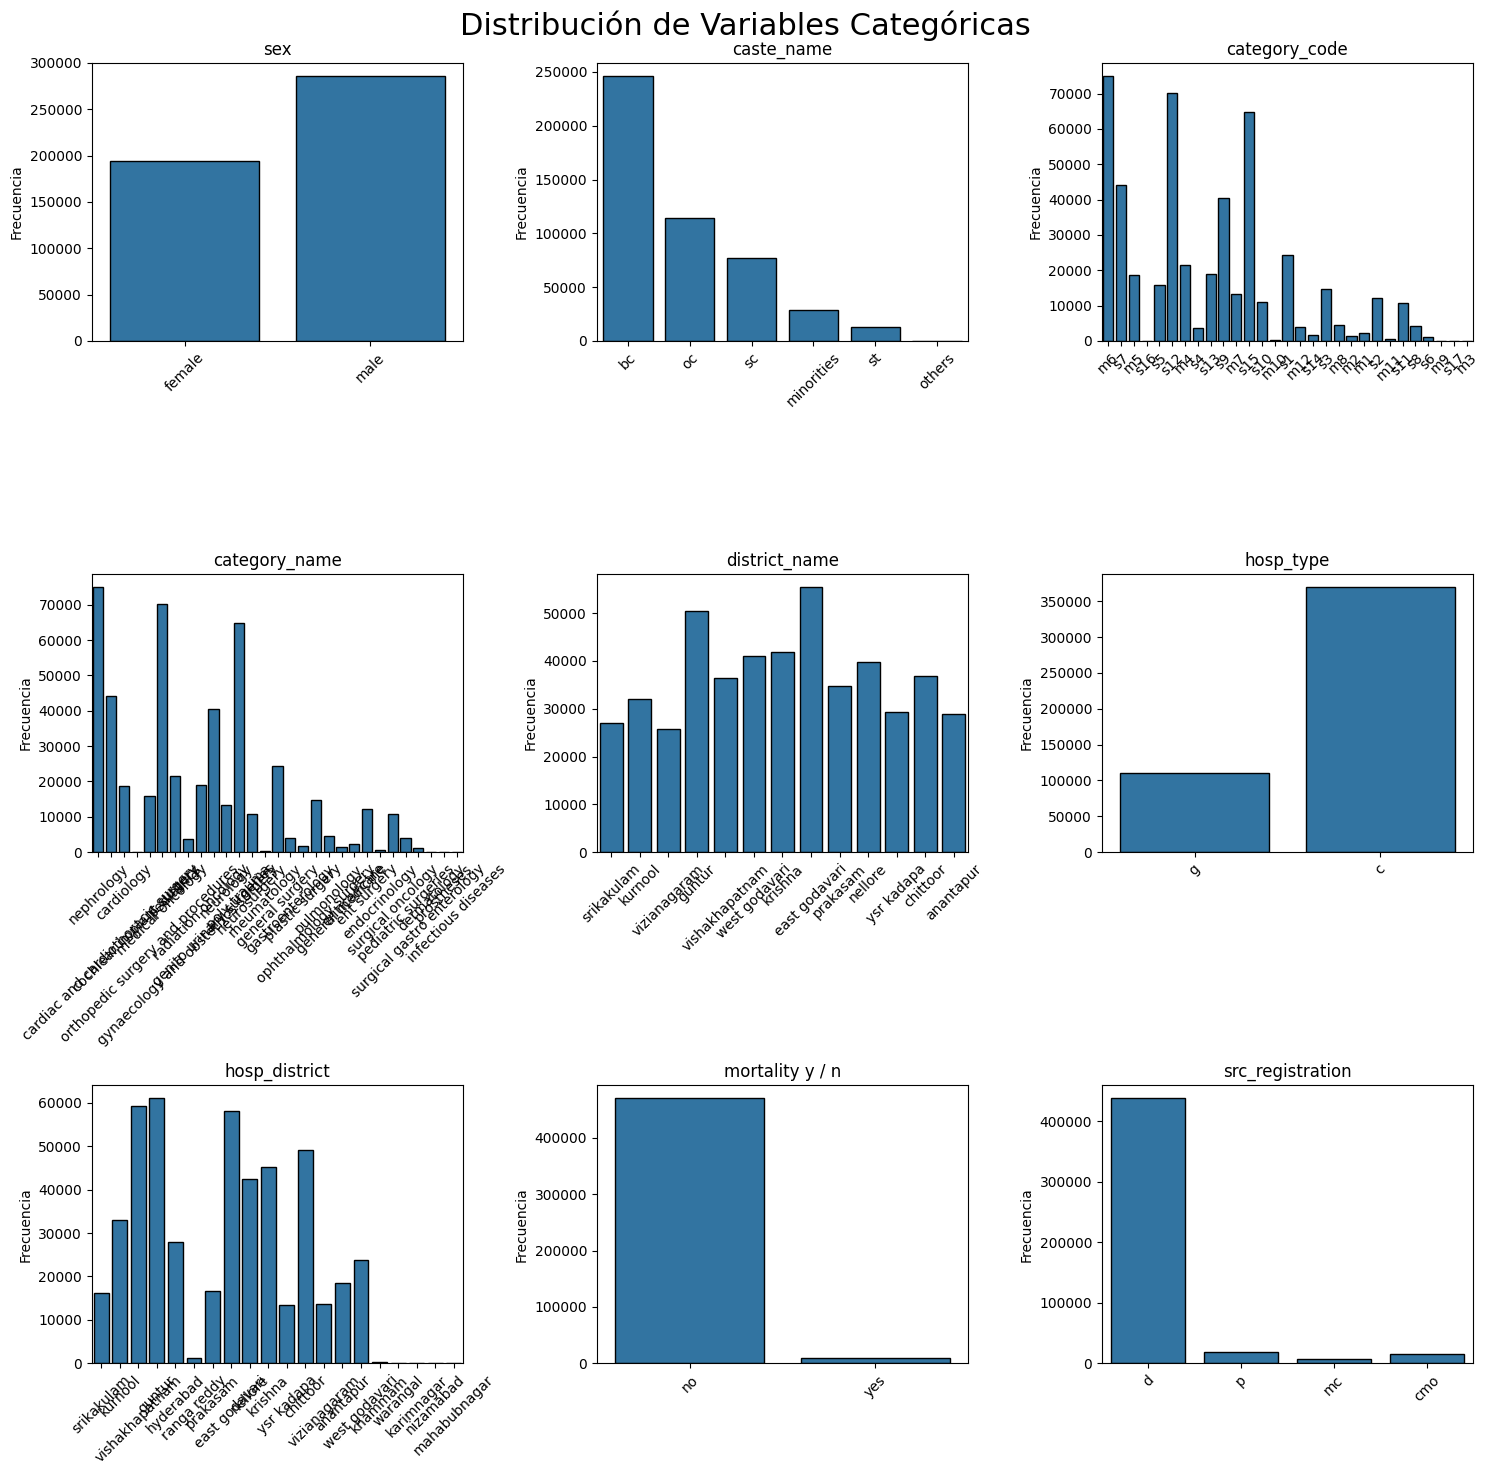

In [66]:
# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro por cantidad de categorías
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    sns.countplot(
        data=df,
        x=col,
        dodge=False,
        edgecolor="black",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Categóricas", fontsize=22)
plt.tight_layout()
plt.savefig("figures/00_distribucion_categoricas.png", bbox_inches="tight")
plt.show()

### Variables numéricas

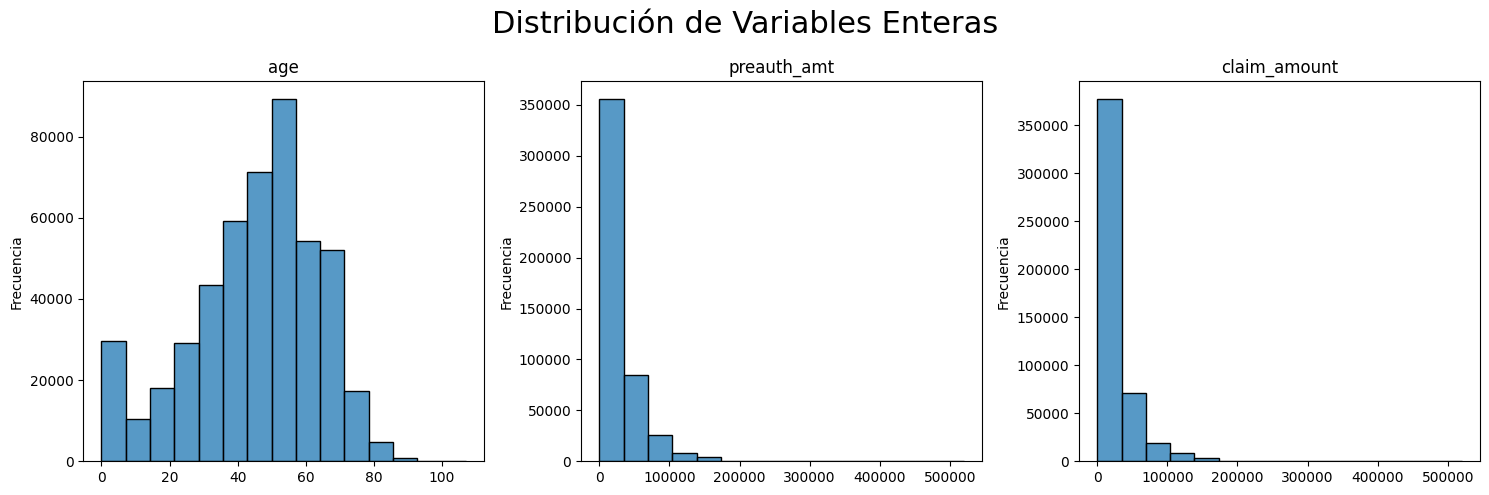

In [67]:
# seleccionar variables enteras
int_cols = df.select_dtypes(include=["int64", "int32"]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    
    sns.histplot(data=df, x=col, bins=15, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Enteras", fontsize=22)
plt.tight_layout()
plt.savefig("figures/00_distribucion_numericas.png", bbox_inches="tight")
plt.show()

## Mortalidad

In [68]:
df["mortality y / n"].value_counts()

mortality y / n
no     469566
yes     10122
Name: count, dtype: int64

In [69]:
df["mortality"] = df["mortality y / n"].map({"yes": 1, "no": 0})

In [70]:
def mortality_groups(df:pd.DataFrame, groupby:str | list[str], sortby:str | None = "mortality_pct", obs:bool = True, show:bool = True) -> pd.DataFrame:
    results = df.groupby(groupby, observed=obs)["mortality"].agg(["count", "sum", "mean"]).reset_index()
    results.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
    results["mortality_pct"] *= 100
    if sortby:
        results.sort_values(sortby, ascending=False, inplace=True)
    if show: display(results)
    return results

### Mortalidad vs is_child

In [71]:
childs = df[df["is_child"]].copy()
adults = df[~df["is_child"]].copy()
print("Número de filas en el dataset original:", df.shape[0])
print("Número de filas con edad <= 14 (niños):", childs.shape[0])
print("Número de filas con edad > 14 (adultos):", adults.shape[0])

Número de filas en el dataset original: 479688
Número de filas con edad <= 14 (niños): 39994
Número de filas con edad > 14 (adultos): 439694


In [72]:
subsets = {
    "Total": df,
    "Adultos (edad > 14)": adults,
    "Niños (edad <= 14)": childs,
}

In [73]:
mortality_childs_vs_adults = pd.DataFrame({
        "subset": subsets.keys(),
        "n_rows": [subset.shape[0] for subset in subsets.values()],
        "mortality_count": [subset["mortality"].sum() for subset in subsets.values()],
        "mortality_pct": [subset["mortality"].mean()*100 for subset in subsets.values()],
})
mortality_childs_vs_adults

,subset,n_rows,mortality_count,mortality_pct
0,Total,479688,10122,2.1101
1,Adultos (edad > 14),439694,9082,2.0655
2,Niños (edad <= 14),39994,1040,2.6004


mortalidad en niños ligeramente mayor que en adultos, e incluso más alta que el promedio general

### Mortalidad vs grupo etario

In [74]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[-1, 5, 11, 18, 30, 60, 80, np.inf],
    labels=["0-5", "6-11", "12-18", "19-30", "31-60", "61-80", "80+"]
)

In [75]:
mortality_by_age_group = mortality_groups(df, "age_group", sortby=None)

,age_group,n_rows,mortality_count,mortality_pct
0,0-5,27130,946,3.4869
1,6-11,7668,46,0.5999
2,12-18,14528,177,1.2183
3,19-30,48873,676,1.3832
4,31-60,280059,5255,1.8764
5,61-80,98298,2900,2.9502
6,80+,3132,122,3.8953


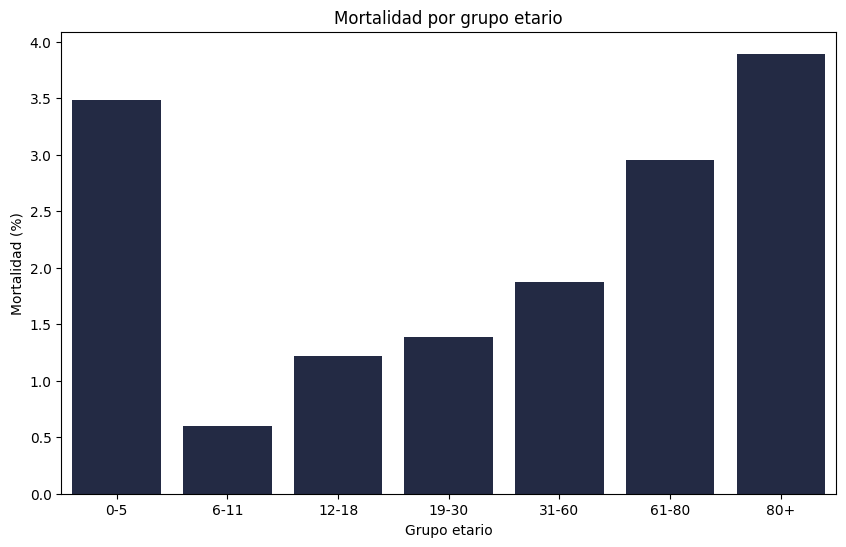

In [76]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_age_group, x="age_group", y="mortality_pct", color="#1E2749")
plt.title("Mortalidad por grupo etario")
plt.xlabel("Grupo etario")
plt.ylabel("Mortalidad (%)")
plt.savefig("figures/01_mortalidad_grupo_etario.png", bbox_inches="tight")
plt.show()


alta mortalidad en recién nacidos y adultos mayores. comportamiento ascendente desde niñez, donde se observan los valores más bajos de tasa de mortalidad con `0,6 %`

### Mortalidad vs grupo etario y sexo

In [77]:
mortality_by_age_group_and_sex = mortality_groups(df, ["age_group", "sex"], sortby=None)

,age_group,sex,n_rows,mortality_count,mortality_pct
0,0-5,female,10715,344,3.2105
1,0-5,male,16415,602,3.6674
2,6-11,female,2588,23,0.8887
3,6-11,male,5080,23,0.4528
4,12-18,female,4258,88,2.0667
5,12-18,male,10270,89,0.8666
6,19-30,female,14727,277,1.8809
7,19-30,male,34146,399,1.1685
8,31-60,female,119331,1755,1.4707
9,31-60,male,160728,3500,2.1776


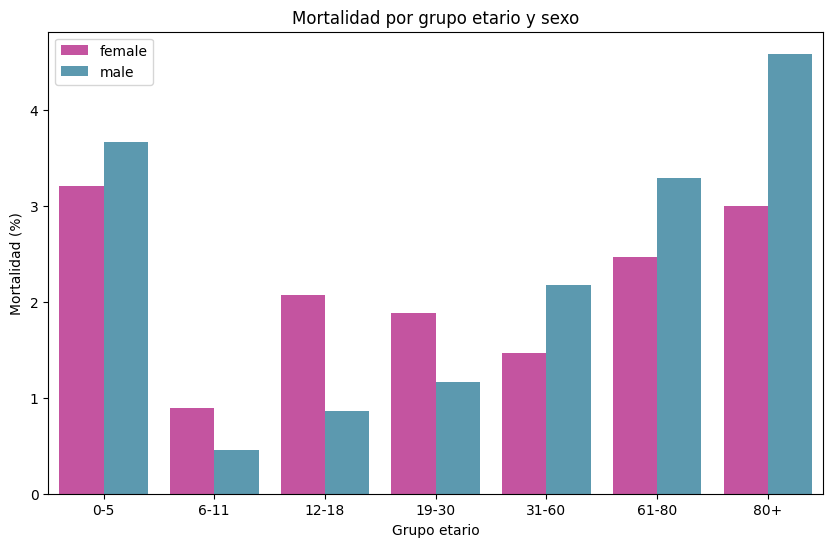

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_age_group_and_sex, x="age_group", y="mortality_pct", hue="sex", palette={"female": "#D741A7", "male": "#4E9FBD"})
plt.title("Mortalidad por grupo etario y sexo")
plt.xlabel("Grupo etario")
plt.ylabel("Mortalidad (%)")
plt.legend()
plt.savefig("figures/02_mortalidad_grupo_etario_y_sexo.png", bbox_inches="tight")
plt.show()

En recién nacidos y niñez se observan las menores discrepancias, con valores de `~0,4` puntos porcentuales, primero con sexo masculino por encima del femenino, y al contrario en el grupo de niñez. Es en este grupo donde comienza a aumentar sustancialmente la tasa de mortalidad en el sexo femenino, alcanzando un pico en el grupo de adolescencia, donde se observa un porcentaje de mortalidad de `2,07 %`. En contraste, el sexo masculino contempla un aumento sostenido, pero por debajo de su contraparte, tomando valores desde `0,45 %` hasta `1,17 %`. 

Esta situación se revierte al alcanzar la adultez, donde el sexo femenino tiene un mínimo local, alrededor del `1,47 %`, siendo superado por el sexo masculino, que continua ampliando la diferencia hasta alcanzar el máximo absoluto a nivel general, con una tasa de mortalidad de `4,59 %`, mientras que, en el otro grupo, se observa una tasa del `3,00 %`.

a realizar: 
* analizar por qué en la niñez, adolescencia y juventud, el sexo femenino tiene tasas de mortaliadad más elevadas, para luego tener una baja en la adultez, donde los hombres comienzan a tener tasas de mortalidad más altas, incluso hasta en las edades más altas observadas en el dataset
* indagar en categorías de cirugías y cirugías riesgosas (relacionadas a altas tasas de mortalidad) y analizar si tienen alguna relación con o si están mas presentes en el sexo femenino

ver cuales son los category_name y surgery más frecuentes en el subset de edad desde 6 hasta 30, para el sexo femenino. investigar cuáles son las tasas de mortalidad de estas cirugías a nivel general en todo el dataset. tratar de calcular si la alta mortalidad está dada por las cirugías (riesgosas) o por las condiciones del paciente. es decir, averiguar si la alta tasa de mortalidad en este subgrupo está dado por la alta frecuencia de cirugias riesgosas o si las cirugías que aparecen tienen una ala tasa de mortalidad debido a que la mayoría de los pacientes pertenecían a estos grupos (mayor probabilidad de mortalidad). e intentar determinar si existe relación entre: ser mujer, tener entre 6 y 30 años y operarse de esas cirugías en específico.

### Mortalidad vs edad

In [79]:
mortality_by_age = mortality_groups(df, "age", sortby=None, obs=False, show=False)

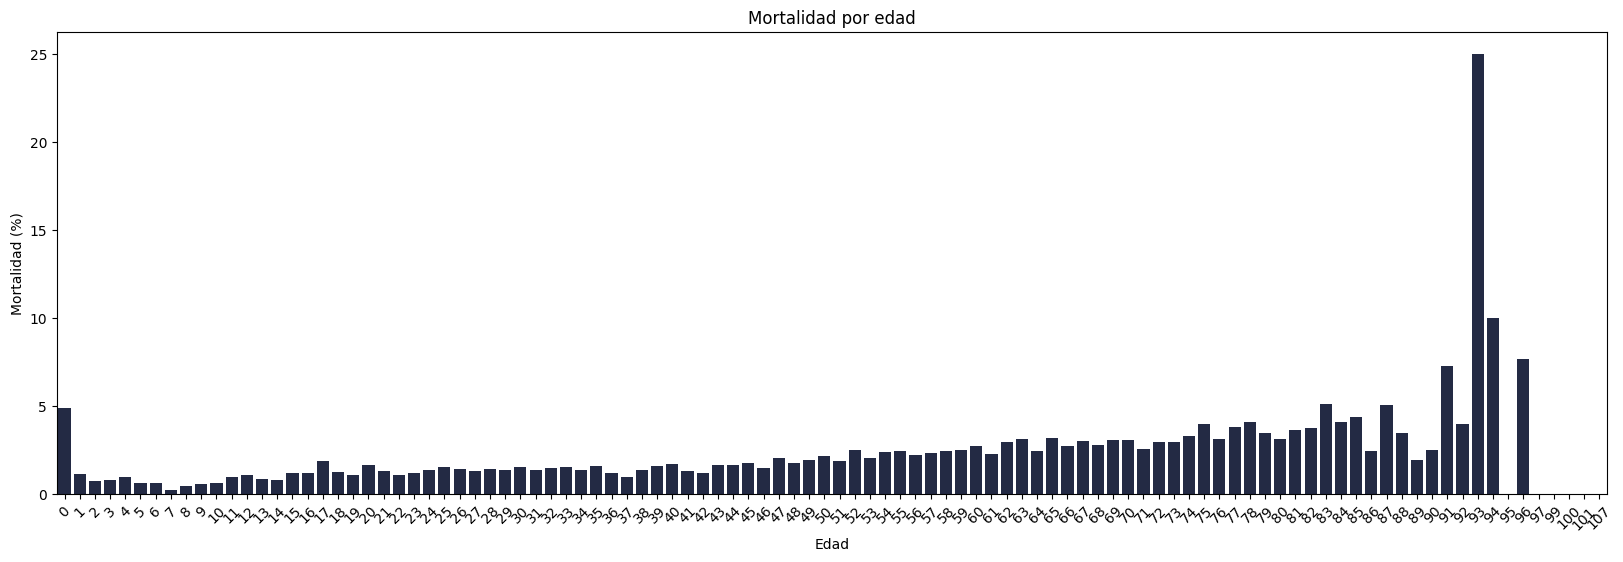

In [80]:
plt.figure(figsize=(20, 6))
sns.barplot(data=mortality_by_age, x="age", y="mortality_pct", color="#1E2749")
plt.title("Mortalidad por edad")
plt.xlabel("Edad")
plt.ylabel("Mortalidad (%)")
plt.tick_params(axis="x", rotation=45)
plt.savefig("figures/03_mortalidad_por_edad.png", bbox_inches="tight")
plt.show()

### Mortalidad vs edad y sexo

In [81]:
mortality_by_age_and_sex = mortality_groups(df, ["age", "sex"], sortby=None, obs=False, show=False)

In [82]:
mortality_by_age_and_sex = mortality_by_age_and_sex[mortality_by_age_and_sex["n_rows"]>30]

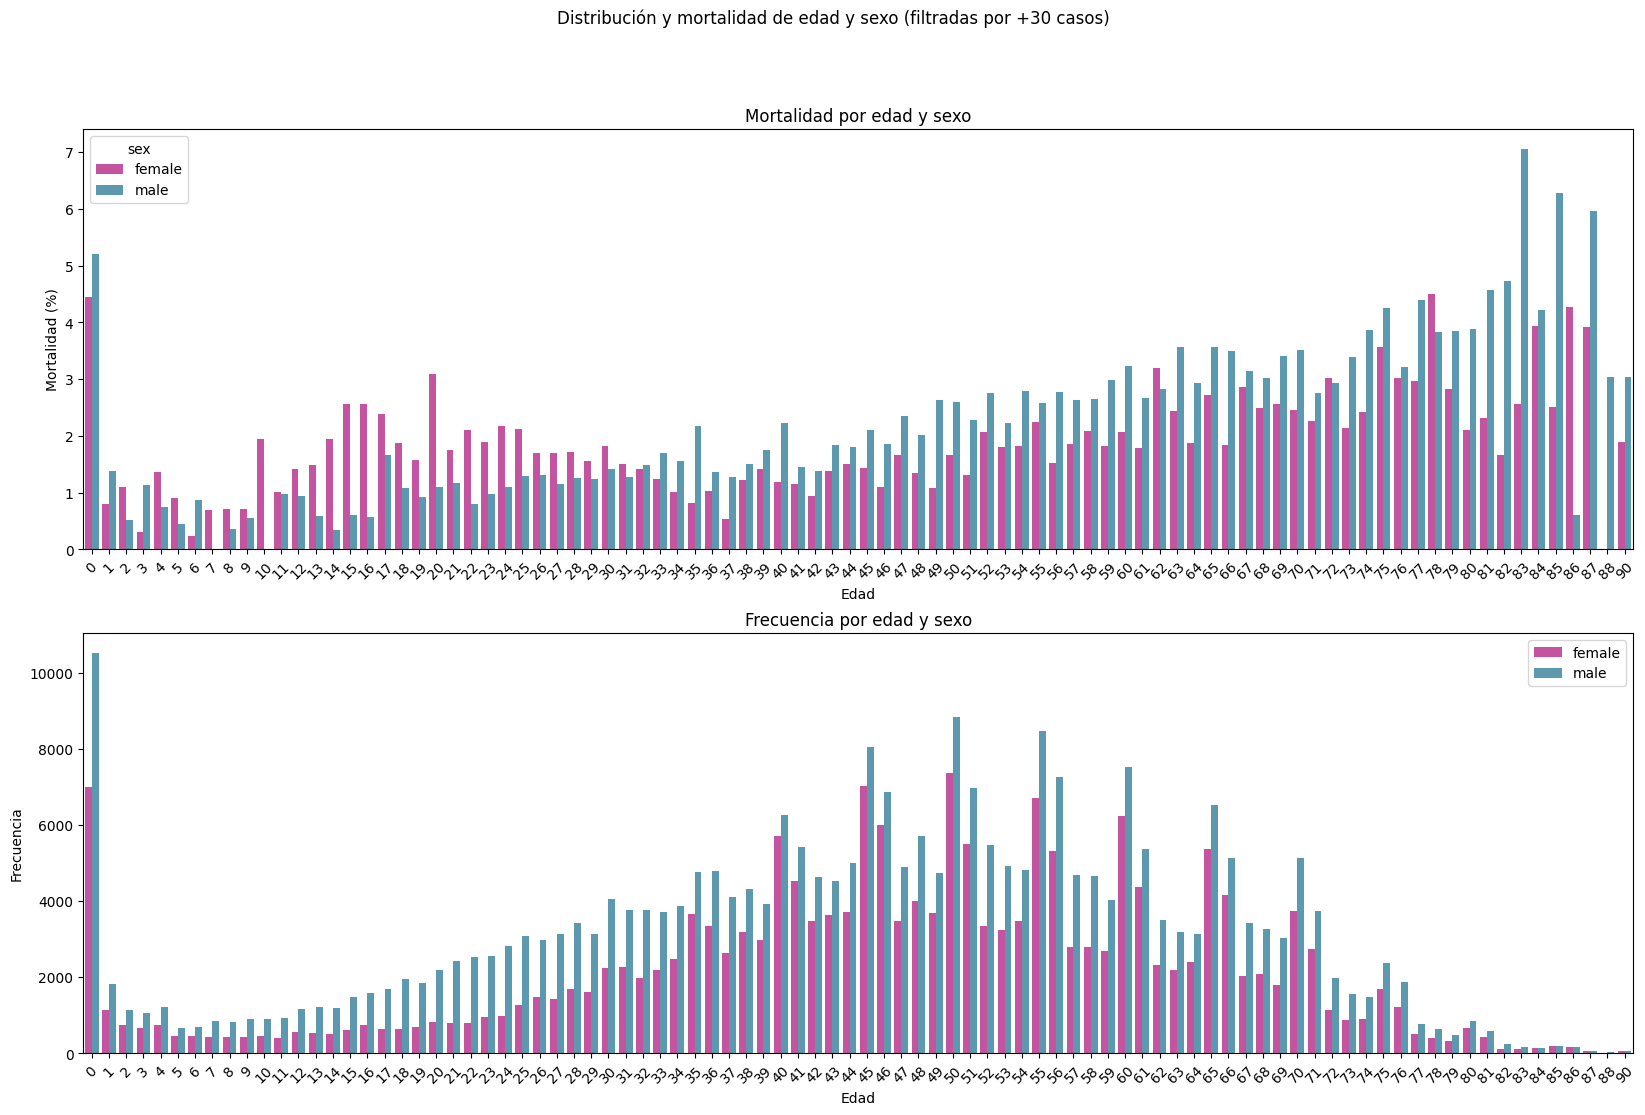

In [83]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))
axes = axes.flatten()
sns.barplot(data=mortality_by_age_and_sex, x="age", y="mortality_pct", hue="sex", palette={"female": "#D741A7", "male": "#4E9FBD"}, ax=axes[0])
axes[0].set_title("Mortalidad por edad y sexo")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Mortalidad (%)")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=mortality_by_age_and_sex, x="age", y="n_rows", hue="sex", palette={"female": "#D741A7", "male": "#4E9FBD"}, ax=axes[1])
axes[1].set_title("Frecuencia por edad y sexo")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Distribución y mortalidad de edad y sexo (filtradas por +30 casos)")
plt.savefig("figures/04_mortalidad_frecuencia_edad_sexo.png", bbox_inches="tight")
plt.legend()
plt.show() 

no parece haber inconsistencias en la cantidad de filas para las edades que nos son de interés analizar la separación entre femenino y masculino, lo que podría indicar que las tasas de mortalidad de los grupos etarios de niñez, adolescencia y juventud son aproximaciones o estadísticos robustos (?

a realizar
* analizar la tasa de mortalidad de determinadas categorías, agrupado por sexo y filtrado por las edades de interés (misma categoría, misma edad, distinto sexo = distinta tasa de mortalidad?). 
* sacar frecuencias relativas de las categorías de la misma forma (agrupando por sexo y filtrando las edades), (misma edad, distinto sexo = distinta distribución de categorías?). comparar con la distribución (de las categorías) general y la distribución para esos grupos etarios, así como también la distribución por sexo en general. 
* analizar la distribución de tipo de hospital
* analizar la distribución de las castas de los pacientes que presentan mayor mortalidad
* analizar las variables de ubicación, del hospital y del paciente

idea: la mortalidad está dada por ser del sexo femenino y tener esa edad, o por realizarse cirugías más riesgosas en comparación a los hombres? cualquiera de las dos posibilidades invitan a tratar de dibujar conclusiones y seguir con el análisis.

precursores o indicadores que elevan o disminuyen la mortalidad/riesgo de mortalidad

### Mortalidad vs sexo

In [22]:
mortality_by_sex = mortality_groups(df, "sex")

,sex,n_rows,mortality_count,mortality_pct
1,male,285795,6584,2.3037
0,female,193893,3538,1.8247


### Mortalidad vs categoría

In [23]:
mortality_by_category = mortality_groups(df, "category_name")

,category_name,n_rows,mortality_count,mortality_pct
3,critical care,2321,526,22.6626
12,infectious diseases,5,1,20.0000
24,pulmonology,4630,569,12.2894
21,plastic surgery,1682,189,11.2366
15,neurology,13361,1029,7.7015
8,general medicine,1366,88,6.4422
16,neurosurgery,10917,638,5.8441
1,cardiology,18629,831,4.4608
14,nephrology,74947,2995,3.9962
7,gastroenterology,3969,141,3.5525


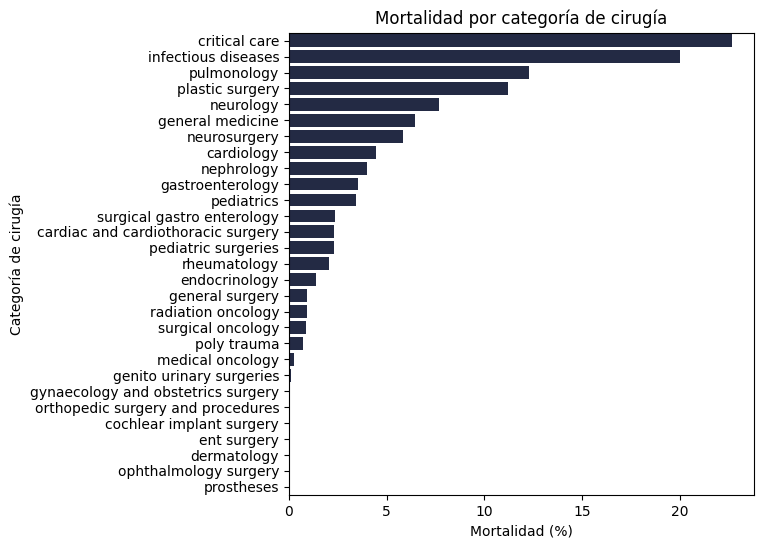

In [24]:
plt.figure(figsize=(6, 6))
sns.barplot(data=mortality_by_category, x="mortality_pct", y="category_name", color="#1E2749", orient="h")
plt.title("Mortalidad por categoría de cirugía")
plt.ylabel("Categoría de cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/05_mortalidad_por_categoria.png", bbox_inches="tight")
plt.show()

hay muchas categorías con tasa de mortalidad cero, que representan riesgo de mortalidad nulo. si queremos analizar los patrones de mortalidad, deberíamos contemplar la diferencia entre estas categorías

In [25]:
mean_mortality = df["mortality"].mean() * 100
print(f"Mortalidad promedio en el dataset: {mean_mortality:.2f}%")
risky_categories = mortality_by_category[mortality_by_category["mortality_pct"] > mean_mortality]
print("Categorías de cirugía con mortalidad por encima del promedio:")
print(risky_categories[["category_name", "mortality_pct"]])

Mortalidad promedio en el dataset: 2.11%
Categorías de cirugía con mortalidad por encima del promedio:
                         category_name  mortality_pct
3                        critical care        22.6626
12                 infectious diseases        20.0000
24                         pulmonology        12.2894
21                     plastic surgery        11.2366
15                           neurology         7.7015
8                     general medicine         6.4422
16                        neurosurgery         5.8441
1                           cardiology         4.4608
14                          nephrology         3.9962
7                     gastroenterology         3.5525
20                          pediatrics         3.4161
27          surgical gastro enterology         2.3360
0   cardiac and cardiothoracic surgery         2.3257
19                 pediatric surgeries         2.3233


a realizar:
* cruzar esta lista de categorías riesgosas con grupos etarios para ver si hay relación

### Mortalidad vs categoría y sexo

In [26]:
mortality_by_category_and_sex = mortality_groups(df, ["category_name", "sex"], show=False)

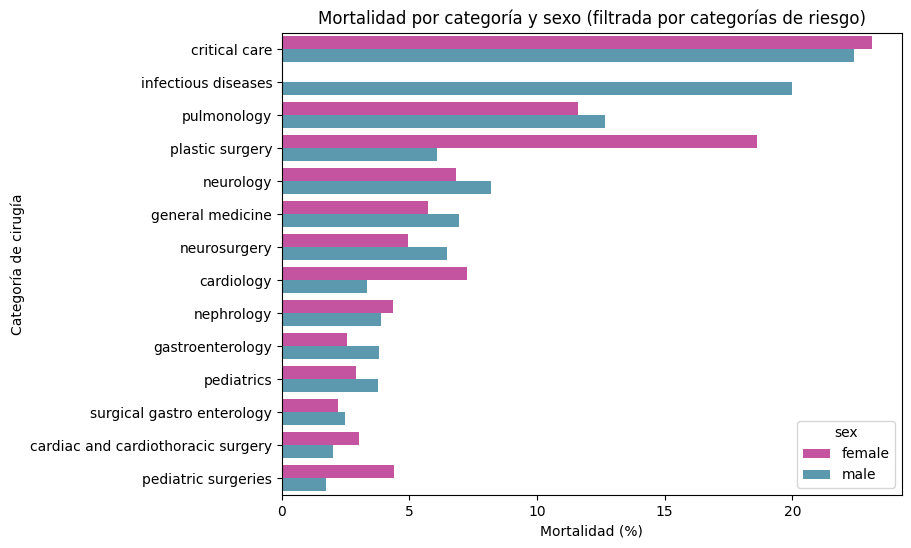

In [27]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=mortality_by_category_and_sex, 
    x="mortality_pct", 
    y="category_name", 
    hue="sex", 
    palette={"female": "#D741A7", "male": "#4E9FBD"}, 
    orient="h", 
    order=risky_categories["category_name"]
)
plt.title("Mortalidad por categoría y sexo (filtrada por categorías de riesgo)")
plt.ylabel("Categoría de cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/06_mortalidad_por_categoria_sexo.png", bbox_inches="tight")
plt.show()


no veo que haya una distinción clara entre las tasas de mortalidad por sexo, dentro de cada categoría de cirugía

### Mortalidad vs cirugía

In [28]:
mortality_by_surgery = mortality_groups(df, "surgery")

,surgery,n_rows,mortality_count,mortality_pct
414,medical management of ards plus dic (blood and blood products),2,2,100.0000
269,gastro study followed by thoracotomy and repairs for oesophageal injury for ...,2,2,100.0000
280,hemimandibulectomy,1,1,100.0000
780,surgical management of above 60% mixed burns,61,57,93.4426
794,surgical management of dissecting aneurysms,4,3,75.0000
...,...,...,...,...
883,twist drill craniostomy,3,0,0.0000
880,triple bypass -pancreas,12,0,0.0000
877,transurethral resection of bladder tumour (turbt),305,0,0.0000
875,trans sphenoidal surgery,10,0,0.0000


In [29]:
top_mortal_surgeries = mortality_by_surgery[mortality_by_surgery["n_rows"]>500].head(20)
top_mortal_surgeries["trunc_surgery"] = top_mortal_surgeries["surgery"].str.replace("medical", "m.").str.replace("management", "m.").str.slice(0, 50)
top_mortal_surgeries

,surgery,n_rows,mortality_count,mortality_pct,trunc_surgery
406,medical management of acute respiratory failure (with ventilator),1118,440,39.3560,m. m. of acute respiratory failure (with ventilato
478,medical management of poisioning requiring ventilatory assistance,598,129,21.5719,m. m. of poisioning requiring ventilatory assistan
525,medical management of term baby with severe perinatal asphyxia clinically ev...,606,91,15.0165,m. m. of term baby with severe perinatal asphyxia
436,medical management of copd with respiratory failure (infective exacerbation),1006,148,14.7117,m. m. of copd with respiratory failure (infective
450,medical management of hemorrhagic stroke/strokes(i61/i62/i63/i64),3078,414,13.4503,m. m. of hemorrhagic stroke/strokes(i61/i62/i63/i6
312,intesive care managementof neuro surgical trauma in neuro icu @rs.4000/day,1337,176,13.1638,intesive care m.of neuro surgical trauma in neuro
853,temporary pacemaker implantation,842,106,12.5891,temporary pacemaker implantation
411,medical management of aki,1649,185,11.2189,m. m. of aki
838,surgical treatment for acute intestinal perforation,963,101,10.4881,surgical treatment for acute intestinal perforatio
533,medicalmanagement of preterm baby of 33 to 34 weeks with mild hyaline membra...,998,93,9.3186,m.m. of preterm baby of 33 to 34 weeks with mild h


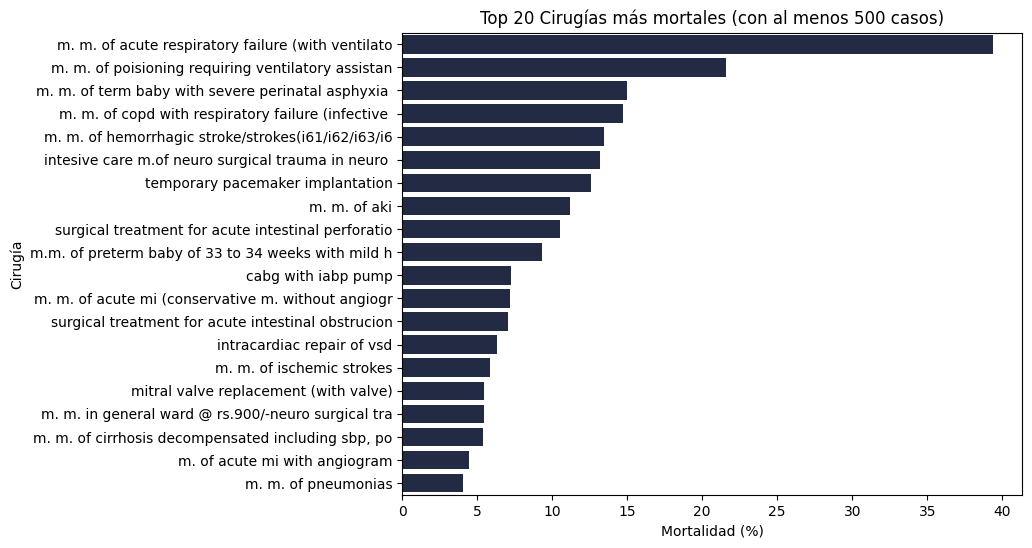

In [30]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_mortal_surgeries, 
    x="mortality_pct", 
    y="trunc_surgery", 
    orient="h",
    color="#1E2749"
)
plt.title("Top 20 Cirugías más mortales (con al menos 500 casos)")
plt.ylabel("Cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/07_mortalidad_por_cirugia.png", bbox_inches="tight")
plt.show()

a realizar:
* tratar de identificar categorías o patrones implícitos en las cirugías de mayor riesgo. 
* identificar los grupos etarios, castas y géneros de las mismas
* promedio de amt para cirugía

### Mortalidad vs tipo de hospital

In [31]:
hosp_type_mapping = {
    "g": "government",
    "c": "corporate"
}
df["hosp_type"] = df["hosp_type"].map(hosp_type_mapping)

In [32]:
mortality_by_hosp_type = mortality_groups(df, "hosp_type")

,hosp_type,n_rows,mortality_count,mortality_pct
1,government,110342,3994,3.6197
0,corporate,369346,6128,1.6591


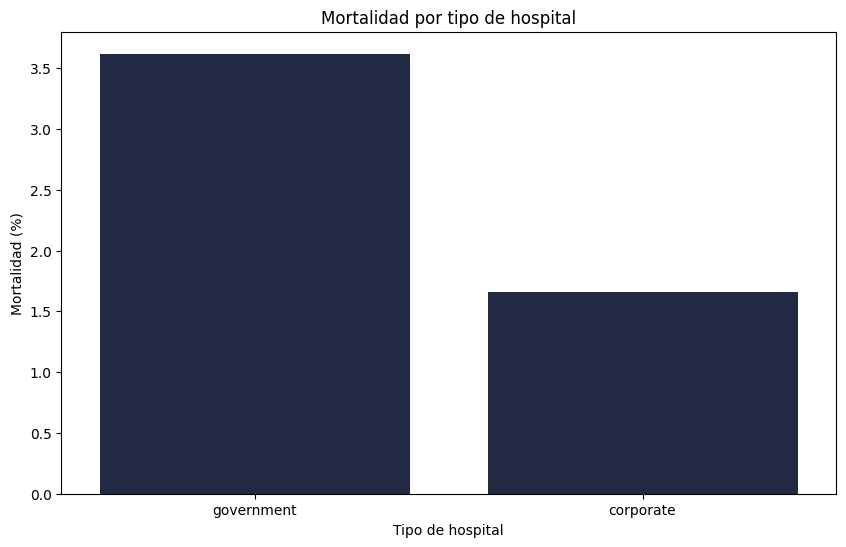

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_hosp_type, y="mortality_pct", x="hosp_type", color="#1E2749")
plt.title("Mortalidad por tipo de hospital")
plt.xlabel("Tipo de hospital")
plt.ylabel("Mortalidad (%)")
plt.savefig("figures/08_mortalidad_tipo_hospital.png", bbox_inches="tight")
plt.show()

In [34]:
df_risky_surgeries = df[df["category_name"].isin(risky_categories["category_name"])].copy()

In [35]:
mortality_by_hosp_type_risky_cat = mortality_groups(df_risky_surgeries, "hosp_type")

,hosp_type,n_rows,mortality_count,mortality_pct
1,government,60019,3425,5.7065
0,corporate,142828,5469,3.8291


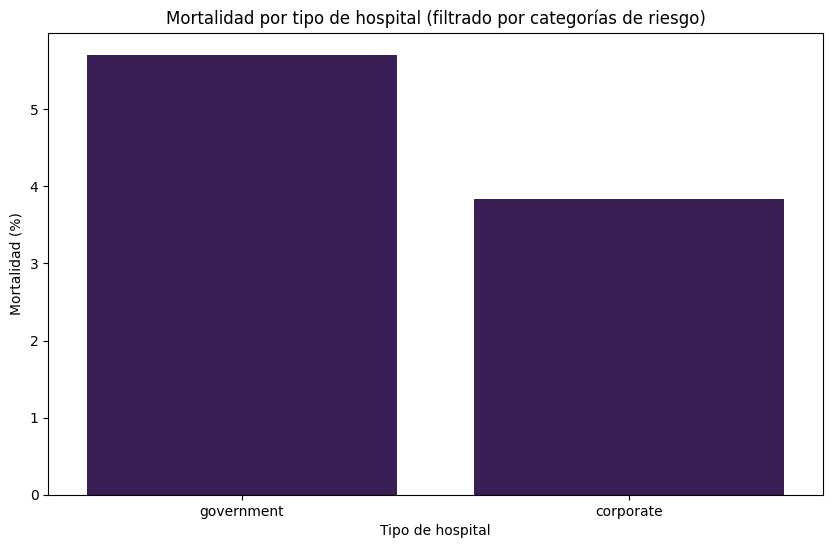

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_hosp_type_risky_cat, y="mortality_pct", x="hosp_type", color="#38165E")
plt.title("Mortalidad por tipo de hospital (filtrado por categorías de riesgo)")
plt.xlabel("Tipo de hospital")
plt.ylabel("Mortalidad (%)")
plt.savefig("figures/09_mortalidad_tipo_hospital_cat_riesgo.png", bbox_inches="tight")
plt.show()

### Mortalidad vs categoría de cirugía por tipo de hospital

In [37]:
mortality_by_category_and_hosp_type = mortality_groups(df, ["category_name", "hosp_type"], show=False)

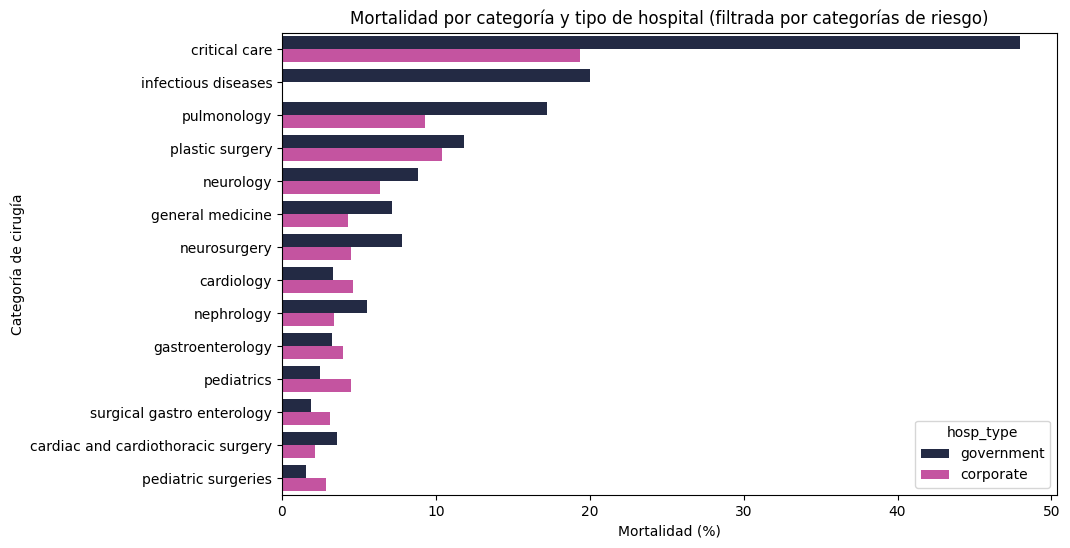

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=mortality_by_category_and_hosp_type, 
    x="mortality_pct", 
    y="category_name", 
    hue="hosp_type", 
    palette={"government": "#1E2749", "corporate": "#D741A7"}, 
    orient="h", 
    order=risky_categories["category_name"]
)
plt.title("Mortalidad por categoría y tipo de hospital (filtrada por categorías de riesgo)")
plt.ylabel("Categoría de cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/10_mortalidad_categoria_tipo_hospital.png", bbox_inches="tight")
plt.show()

### Mortalidad vs hospital

In [39]:
mortality_by_hosp = mortality_groups(df, ["hosp_name", "hosp_district"])

,hosp_name,hosp_district,n_rows,mortality_count,mortality_pct
251,nikhil hospital,hyderabad,5,2,40.0000
427,tulasi hospitals a unit of life shine medical services pvt ltd,ranga reddy,3,1,33.3333
319,s.v.s hospital,mahabubnagar,6,1,16.6667
355,sree hospital,chittoor,28,4,14.2857
385,sri sai seven hills hospitals a division of edukondalu multi speciality hosp...,chittoor,21,3,14.2857
...,...,...,...,...,...
458,viswa orthopaedic hospital,chittoor,767,0,0.0000
456,visakha hospitals and diagnostics ltd care hospital iii,vishakhapatnam,86,0,0.0000
455,virinchi healthcare private limted,hyderabad,56,0,0.0000
452,vijaya hospitals,west godavari,37,0,0.0000


In [40]:
top_mortal_hospitals = mortality_by_hosp[mortality_by_hosp["n_rows"]>500].head(20)
top_mortal_hospitals

,hosp_name,hosp_district,n_rows,mortality_count,mortality_pct
154,gsl medical college and gsl general hospital,east godavari,1921,162,8.4331
6,abhaya kidney care mulityspeciality hospital,anantapur,799,67,8.3855
274,pes institute of medical sciences and research hospital,chittoor,2427,185,7.6226
149,govt general hospital kurnool,kurnool,10250,770,7.5122
22,andhra health diagnostic services limitedglobal vijayawada,krishna,1292,93,7.1981
175,kala hospitals p ltd,vishakhapatnam,1762,121,6.8672
245,narayana medical college hospital,nellore,9342,542,5.8018
255,nims hospitals,hyderabad,3036,167,5.5007
14,alluri sitarama raju academy of medical sciences asram hospital,west godavari,5727,309,5.3955
391,sri vijaya durga cardiac centre,kurnool,577,31,5.3726


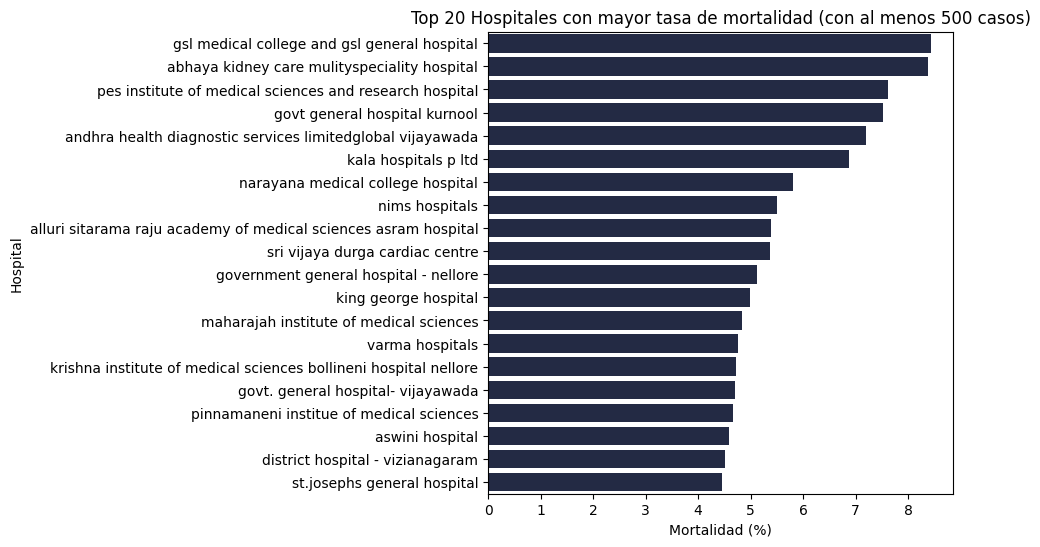

In [41]:
plt.figure(figsize=(6, 6))
sns.barplot(
    data=top_mortal_hospitals, 
    x="mortality_pct", 
    y="hosp_name", 
    orient="h",
    color="#1E2749"
)
plt.title("Top 20 Hospitales con mayor tasa de mortalidad (con al menos 500 casos)")
plt.ylabel("Hospital")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/11_mortalidad_por_hospital.png", bbox_inches="tight")
plt.show()

### Mortalidad vs distrito del paciente

In [42]:
mortality_by_district = df.groupby("district_name", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_district.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_district["mortality_pct"] *= 100
mortality_by_district = mortality_by_district.sort_values("mortality_pct", ascending=False)
mortality_by_district

,district_name,n_rows,mortality_count,mortality_pct
6,nellore,39836,1255,3.1504
5,kurnool,32013,892,2.7864
11,west godavari,40995,988,2.4101
1,chittoor,36790,862,2.3430
9,vishakhapatnam,36481,794,2.1765
7,prakasam,34819,733,2.1052
4,krishna,41964,840,2.0017
10,vizianagaram,25799,500,1.9381
12,ysr kadapa,29244,542,1.8534
8,srikakulam,27079,497,1.8354


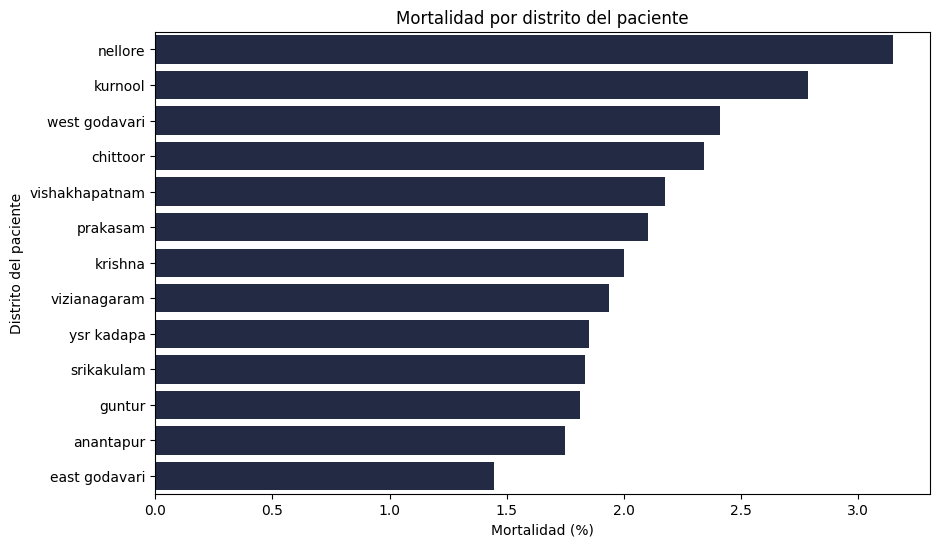

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=mortality_by_district.head(20), 
        x="mortality_pct", 
        y="district_name",
        orient="h",
        color="#1E2749"
)
plt.title("Mortalidad por distrito del paciente")
plt.ylabel("Distrito del paciente")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/12_mortalidad_por_distrito_paciente.png", bbox_inches="tight")
plt.show()

### Mortalidad vs distrito del hospital

In [44]:
mortality_by_hosp_district = mortality_groups(df, "hosp_district")

,hosp_district,n_rows,mortality_count,mortality_pct
9,mahabubnagar,6,1,16.6667
10,nellore,42405,1404,3.3109
6,khammam,346,11,3.1792
8,kurnool,33024,977,2.9585
18,west godavari,23769,678,2.8525
1,chittoor,49172,1169,2.3774
15,vishakhapatnam,59334,1267,2.1354
16,vizianagaram,13563,281,2.0718
12,prakasam,16756,341,2.0351
3,guntur,60988,1228,2.0135


In [45]:
top_mortal_districts = mortality_by_hosp_district[mortality_by_hosp_district["n_rows"]>30]
top_mortal_districts

,hosp_district,n_rows,mortality_count,mortality_pct
10,nellore,42405,1404,3.3109
6,khammam,346,11,3.1792
8,kurnool,33024,977,2.9585
18,west godavari,23769,678,2.8525
1,chittoor,49172,1169,2.3774
15,vishakhapatnam,59334,1267,2.1354
16,vizianagaram,13563,281,2.0718
12,prakasam,16756,341,2.0351
3,guntur,60988,1228,2.0135
14,srikakulam,16137,293,1.8157


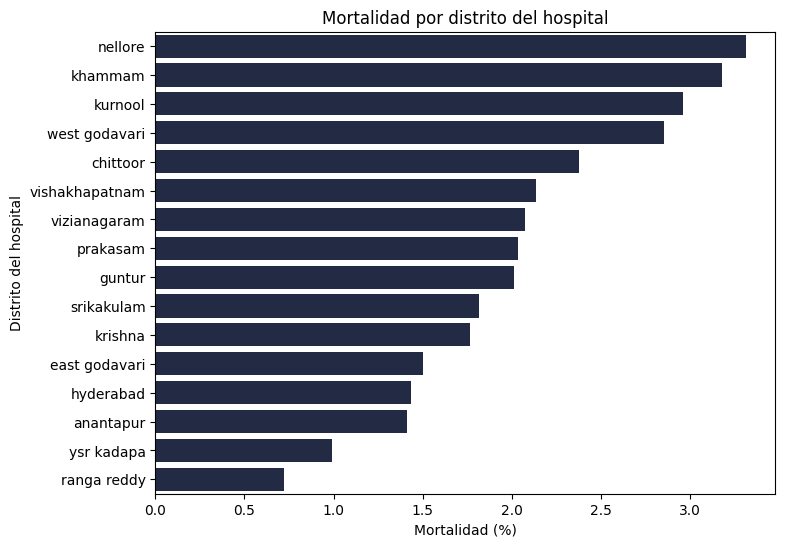

In [46]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_mortal_districts.head(20), 
        x="mortality_pct", 
        y="hosp_district",
        orient="h",
        color="#1E2749"
)
plt.title("Mortalidad por distrito del hospital")
plt.ylabel("Distrito del hospital")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/13_mortalidad_por_distrito_hospital.png", bbox_inches="tight")
plt.show()

### Mortalidad vs casta

In [47]:
mortality_by_caste = mortality_groups(df, "caste_name")

,caste_name,n_rows,mortality_count,mortality_pct
5,st,13138,321,2.4433
3,others,371,9,2.4259
4,sc,76742,1752,2.2830
1,minorities,29150,632,2.1681
0,bc,246164,5132,2.0848
2,oc,114123,2276,1.9943


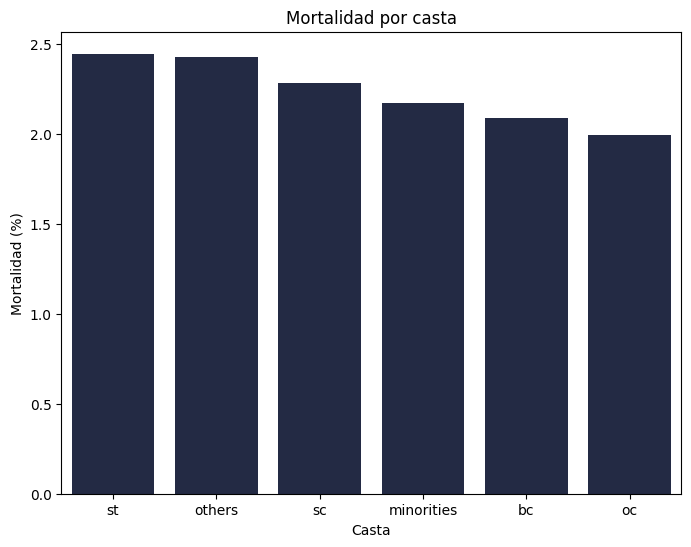

In [48]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=mortality_by_caste, 
        x="caste_name", 
        y="mortality_pct",
        color="#1E2749"
)
plt.title("Mortalidad por casta")
plt.ylabel("Mortalidad (%)")
plt.xlabel("Casta")
plt.savefig("figures/14_mortalidad_por_casta.png", bbox_inches="tight")
plt.show()

## Pre-Auth Amount

In [49]:
amount_cols = [
    "preauth_amt",
    "claim_amount"
    ]

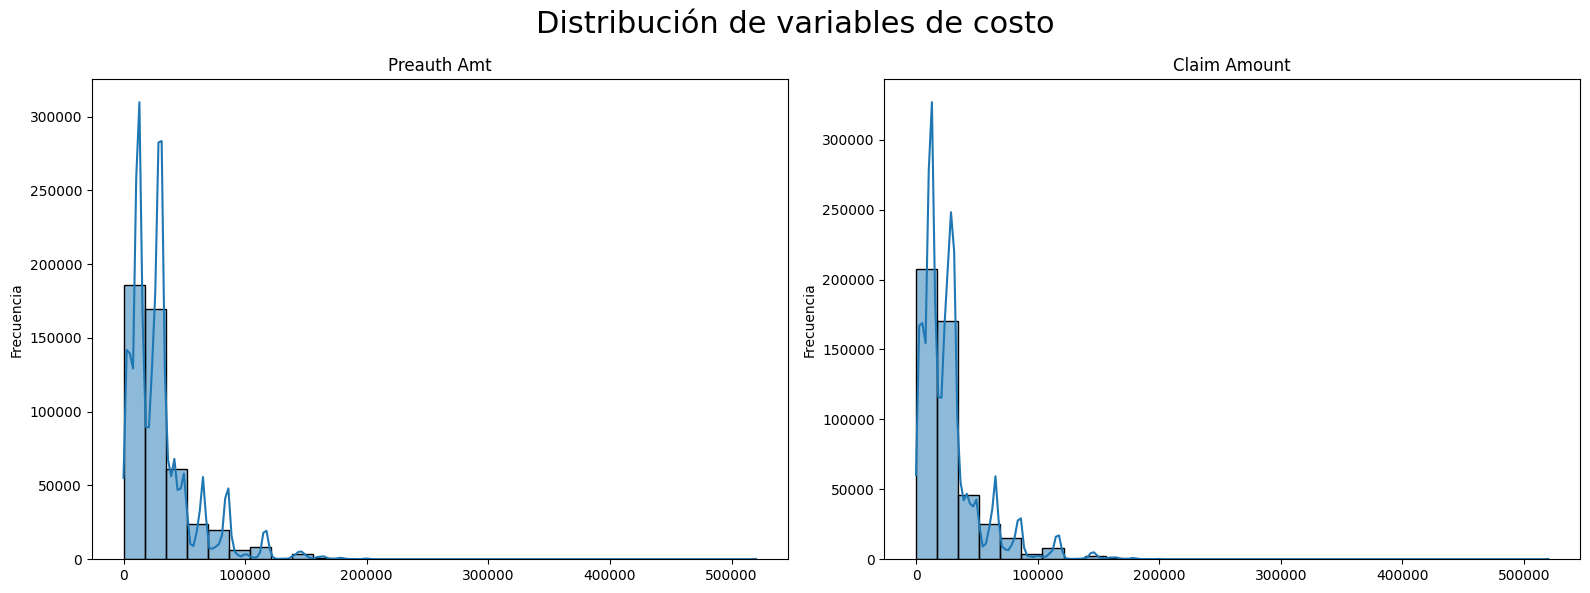

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(amount_cols):
    ax = axes[i]
    
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )

    ax.set_title(to_title_case(col))
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables de costo", fontsize=22)
plt.tight_layout()
plt.savefig("figures/15_distribucion_costos.png", bbox_inches="tight")
plt.show()
   

### Exclusión de outliers

In [51]:
bottom = df["preauth_amt"].quantile(0.01)
top = df["preauth_amt"].quantile(0.99)
print(f"Valor mínimo para preauth_amt (1er percentil): {bottom}")
print(f"Valor máximo para preauth_amt (99º percentil): {top}")

Valor mínimo para preauth_amt (1er percentil): 2000.0
Valor máximo para preauth_amt (99º percentil): 139678.0


In [52]:
df["preauth_amt_cut"] = df[(df["preauth_amt"] > bottom) & (df["preauth_amt"] < top)]["preauth_amt"].copy()
df["preauth_amt_cut"].describe()

count   461106.0000
mean     29804.9410
std      23352.3574
min       2040.0000
25%      12500.0000
50%      25500.0000
75%      35000.0000
max     139546.0000
Name: preauth_amt_cut, dtype: float64

In [53]:
bottom = df["claim_amount"].quantile(0.01)
top = df["claim_amount"].quantile(0.99)
print(f"Valor mínimo para claim_amount (1er percentil): {bottom}")
print(f"Valor máximo para claim_amount (99º percentil): {top}")

Valor mínimo para claim_amount (1er percentil): 2000.0
Valor máximo para claim_amount (99º percentil): 118162.0


In [54]:
df["claim_amount_cut"] = df[(df["claim_amount"] > bottom) & (df["claim_amount"] < top)]["claim_amount"].copy()
df["claim_amount_cut"].describe()

count   458754.0000
mean     26841.7844
std      21495.6503
min       2001.0000
25%      12500.0000
50%      24100.0000
75%      30600.0000
max     118161.0000
Name: claim_amount_cut, dtype: float64

In [55]:
cut_amt_cols = [
    "preauth_amt_cut",
    "claim_amount_cut"
]

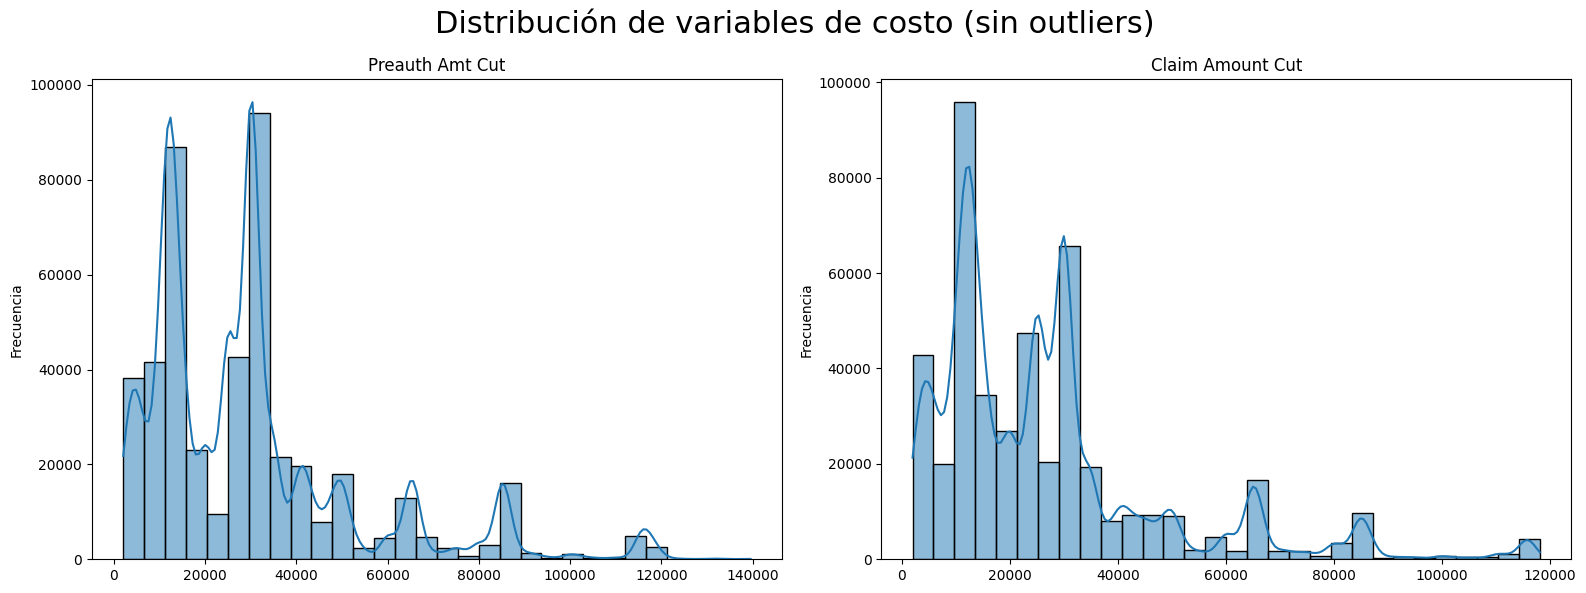

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(cut_amt_cols):
    ax = axes[i]
    
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )

    ax.set_title(to_title_case(col))
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables de costo (sin outliers)", fontsize=22)
plt.tight_layout()
plt.savefig("figures/16_distribucion_costos_sin_outliers.png", bbox_inches="tight")
plt.show()

### Diferencia entre amounts

In [57]:
df["amt_diff"] = df["preauth_amt"] - df["claim_amount"]

In [58]:
df["amt_diff"].describe()

count    479688.0000
mean       2776.7358
std        7731.7858
min     -147900.0000
25%           0.0000
50%           0.0000
75%        1800.0000
max      159543.0000
Name: amt_diff, dtype: float64

### Pre-Auth amount por mortalidad

In [59]:
df["log_preauth_amt"] = np.log10(df["preauth_amt"])
mortality_yes = df[df["mortality"] == 1]
mortality_no = df[df["mortality"] == 0]

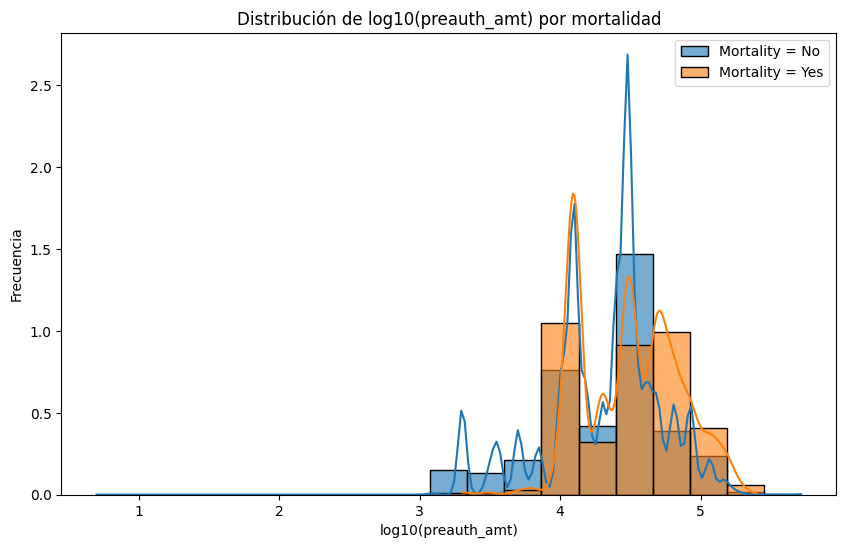

In [60]:
bins = np.linspace(df["log_preauth_amt"].min(), df["log_preauth_amt"].max(), 20)
plt.figure(figsize=(10, 6))
sns.histplot(data=mortality_no, x="log_preauth_amt", bins=bins, kde=True, label="Mortality = No", stat="density", alpha=0.6)
sns.histplot(data=mortality_yes, x="log_preauth_amt", bins=bins, kde=True, label="Mortality = Yes", stat="density", alpha=0.6)
plt.title("Distribución de log10(preauth_amt) por mortalidad")
plt.xlabel("log10(preauth_amt)")
plt.ylabel("Frecuencia")
plt.legend()
#plt.savefig("figures/17_distribucin_preauth_por_mortalidad.png", bbox_inches="tight")
plt.show()

In [61]:
preauth_amt_stats = pd.DataFrame({})
preauth_amt_stats["Total"] = df["preauth_amt"].describe()
preauth_amt_stats["Mortality = No"] = mortality_no["preauth_amt"].describe()
preauth_amt_stats["Mortality = Yes"] = mortality_yes["preauth_amt"].describe()

In [62]:
preauth_amt_stats

,Total,Mortality = No,Mortality = Yes
count,479688.0000,469566.0000,10122.0000
mean,30428.9417,30155.6904,43105.2435
std,27441.5923,27163.9031,35950.6927
min,5.0000,5.0000,2000.0000
25%,12500.0000,12500.0000,12500.0000
50%,25000.0000,25000.0000,30870.0000
75%,35000.0000,35000.0000,60000.0000
max,520000.0000,520000.0000,249543.0000
